In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

measurement_folder = Path("Data/irradiation_measurements")
mak_measurement = measurement_folder / "MAK_physics_dept/cleaned"
CBE_measurement = measurement_folder / "CBE_Data"

In [18]:
cbe_files = list(CBE_measurement.glob("*.csv"))
cbe_files

[PosixPath('Data/irradiation_measurements/CBE_Data/egypt.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/ghana.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/madagascar.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/nigeria.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/somalia.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/kenya.csv')]

In [20]:
location_dict = {
    "Egypt": "egypt",
    "Ghana": "ghana",
    "Kenya": "kenya",
    "Madagascar": "madagascar",
    "Nigeria": "nigeria",
    "Somalia": "somalia",
}

egypt['datetime'] = pd.to_datetime(egypt['datetime'])
ghana['datetime'] = pd.to_datetime(ghana['datetime'])
kenya['datetime'] = pd.to_datetime(kenya['datetime'])
madagascar['datetime'] = pd.to_datetime(madagascar['datetime'])
nigeria['datetime'] = pd.to_datetime(nigeria['datetime'])
somalia['datetime'] = pd.to_datetime(somalia['datetime'])

In [16]:
def plot_yearly_ghi(ax, df, location):
    for year in df['datetime'].dt.year.unique():
        df_year = df[df['datetime'].dt.year == year]
        df_DoY = df_year['datetime'].dt.dayofyear
        ax.plot(df_DoY, df_year['ghi'], label=year)
    # ax.legend()
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('GHI (W/m^2)')
    ax.set_title(f'Yearly GHI for {location}')
    
    return ax

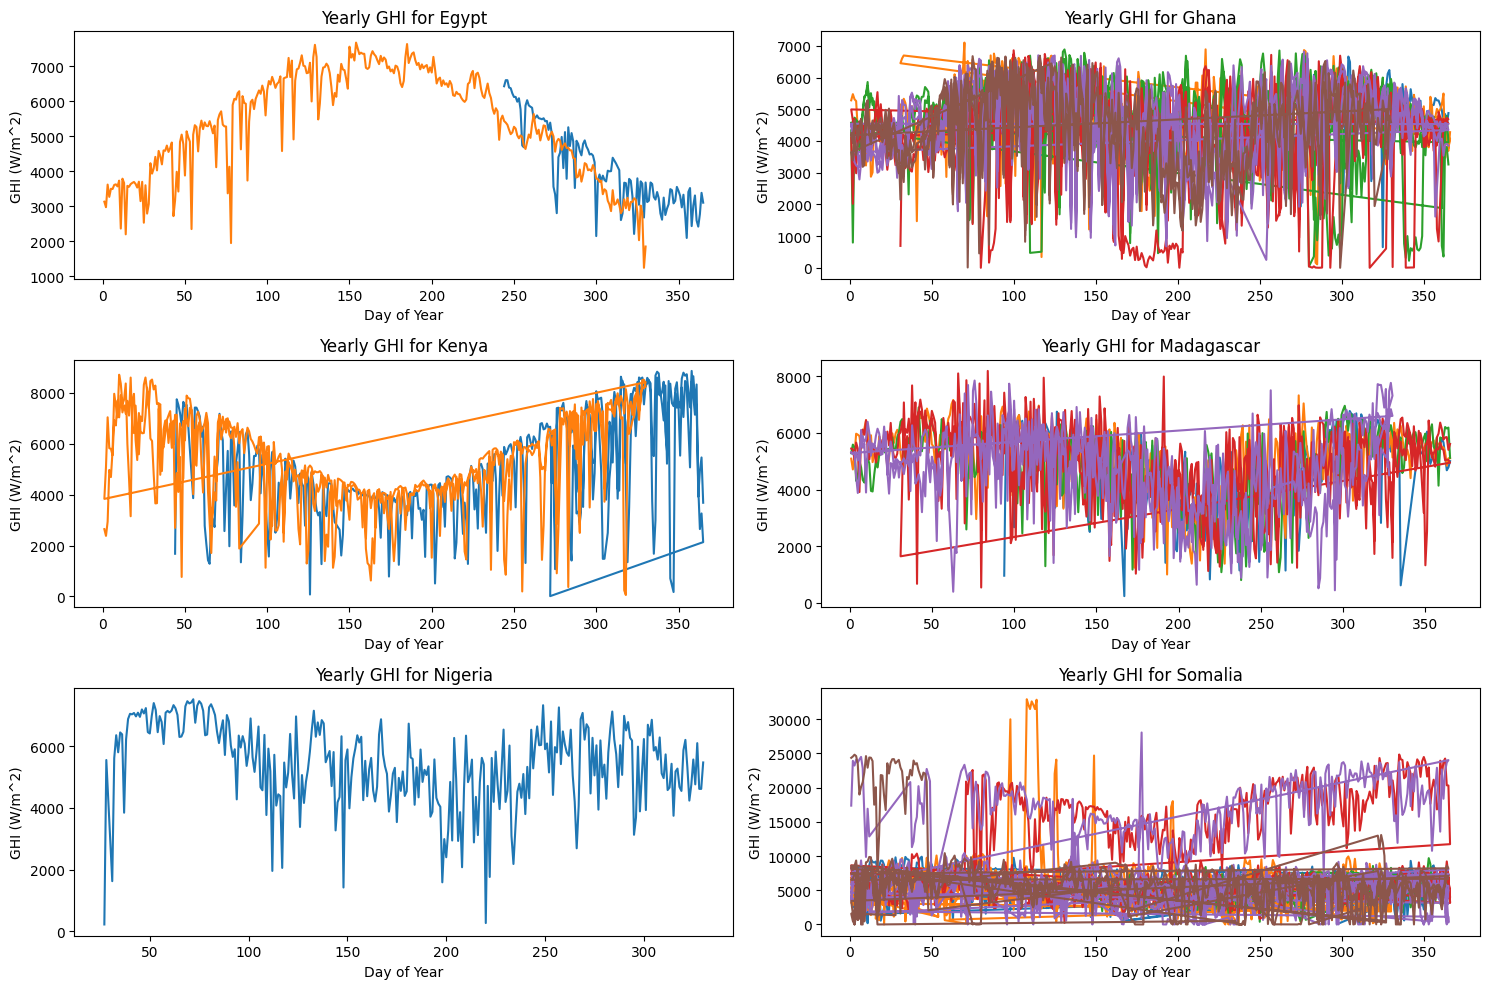

In [17]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

plot_yearly_ghi(ax[0, 0], egypt, 'Egypt')
plot_yearly_ghi(ax[0, 1], ghana, 'Ghana')
plot_yearly_ghi(ax[1, 0], kenya, 'Kenya')
plot_yearly_ghi(ax[1, 1], madagascar, 'Madagascar')
plot_yearly_ghi(ax[2, 0], nigeria, 'Nigeria')
plot_yearly_ghi(ax[2, 1], somalia, 'Somalia')

plt.tight_layout()
plt.show()

## Handling outliers

- Theoretically, the maximum possible daily irradiation in space (extraterrestrial) is about **12,000–13,000** Wh/m²/day at the equator.
- Dropping outliers that exceed 12,000 Wh/m²/day
  
- Theoretically, the minimum possible daily irradiation for regiosn within Egypt and Madagascar is **~1000** Wh/m²/day 
- Dropping values below 500 Wh/m²/day 

In [11]:
# drop valies not within 500 and 13000 Wh/m²/day
def drop_outliers(df):
    return df[(df["ghi"] > 500) & (df["ghi"] < 12000)]

In [7]:
egypt = drop_outliers(egypt)
ghana = drop_outliers(ghana)
kenya = drop_outliers(kenya)
madagascar = drop_outliers(madagascar)
nigeria = drop_outliers(nigeria)
somalia = drop_outliers(somalia)

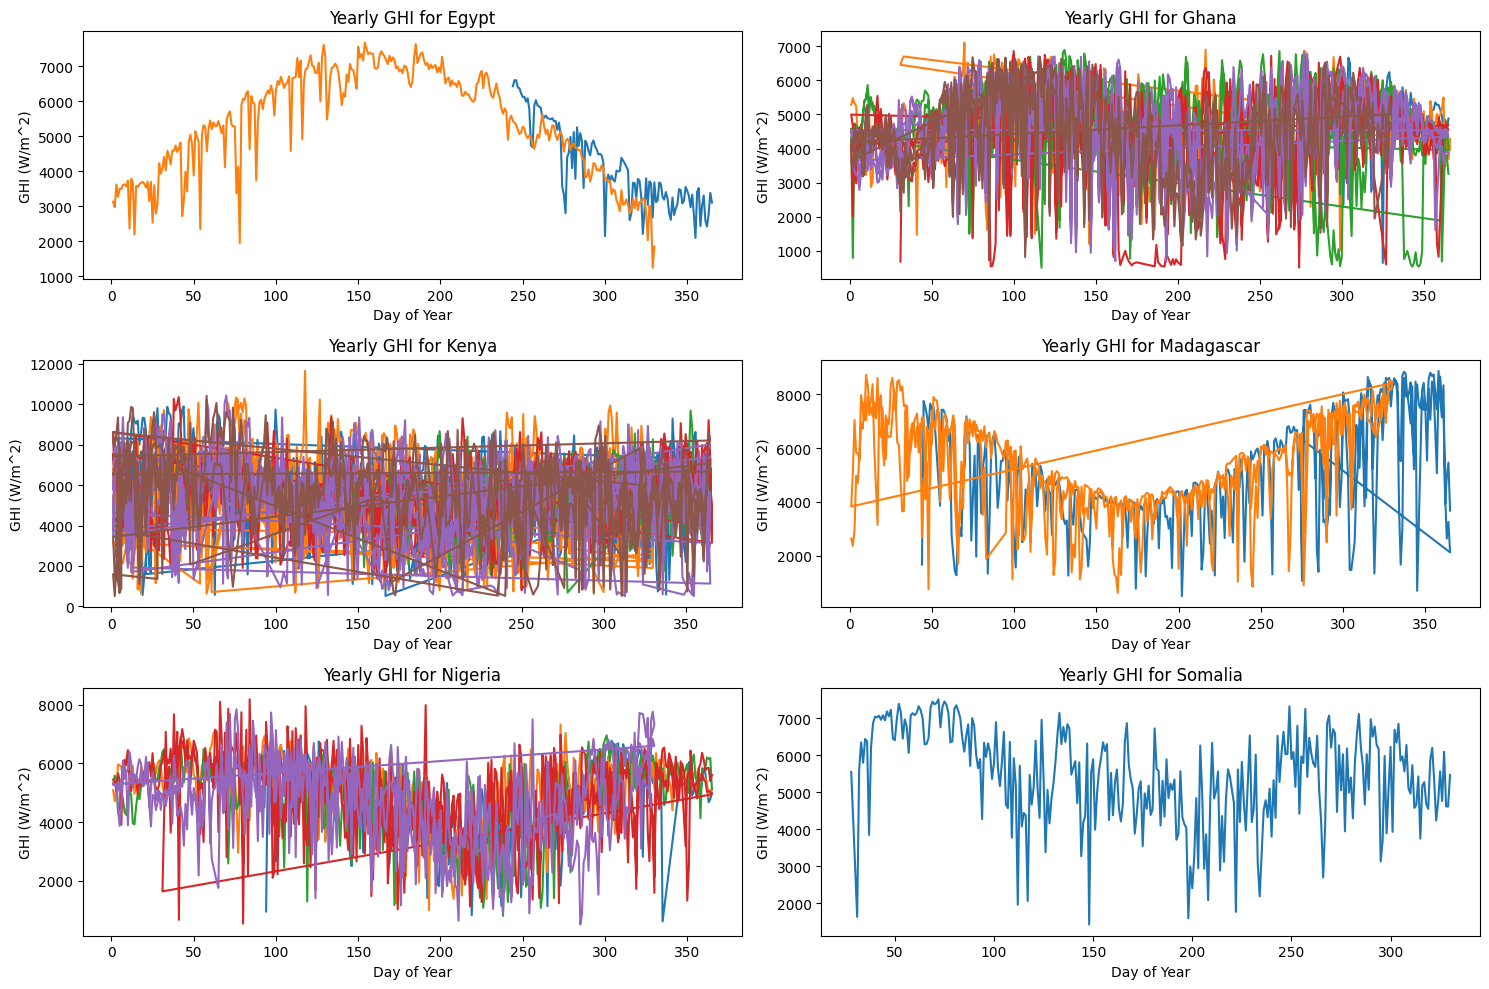

In [8]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

plot_yearly_ghi(ax[0, 0], egypt, 'Egypt')
plot_yearly_ghi(ax[0, 1], ghana, 'Ghana')
plot_yearly_ghi(ax[1, 0], kenya, 'Kenya')
plot_yearly_ghi(ax[1, 1], madagascar, 'Madagascar')
plot_yearly_ghi(ax[2, 0], nigeria, 'Nigeria')
plot_yearly_ghi(ax[2, 1], somalia, 'Somalia')

plt.tight_layout()
plt.show()

In [9]:
def plot_ghi_yearly_distribution(data):
    """
    Create separate figures showing GHI distribution by year and daily statistics for each location.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing 'datetime' and 'ghi' columns
        
    Returns:
    --------
    fig, axes : tuple
        Figure and axes objects for further customization if needed
    """
    # Prepare date-related columns
    data = data.copy()
    data['Date'] = pd.to_datetime(data['datetime'])
    data['Year'] = data['Date'].dt.year
    data['DayOfYear'] = data['Date'].dt.dayofyear
    
    locations = data['location'].unique()
    all_figs = []
    all_axes = []

    for location in locations:
        location_data = data[data['location'] == location]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left plot: GHI for all years overlayed
        years = location_data['Year'].unique()
        color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        colors = [color_list[i % len(color_list)] for i in range(len(years))]

        for j, year in enumerate(years):
            year_data = location_data[location_data['Year'] == year]
            axes[0].plot(year_data['DayOfYear'], year_data['ghi'], 
                        color=colors[j], alpha=0.7, label=str(year))

        axes[0].set_xlabel('Day of Year')
        axes[0].set_ylabel('GHI (W/m²)')
        axes[0].set_title(f'Daily GHI Values in {location.capitalize()} by Year')
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        # Right plot: Daily mean and std across years
        daily_stats = location_data.groupby(['DayOfYear'])['ghi'].agg(['mean', 'std']).reset_index()

        axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'], 
                    color='blue', label='Mean GHI')
        axes[1].fill_between(
            daily_stats['DayOfYear'], 
            daily_stats['mean'] - daily_stats['std'], 
            daily_stats['mean'] + daily_stats['std'], 
            color='blue', alpha=0.2, label='± 1 Std Dev'
        )

        axes[1].set_xlabel('Day of Year')
        axes[1].set_ylabel('GHI (W/m²)')
        axes[1].set_title(f'Mean Daily GHI with Standard Deviation in {location.capitalize()}')
        axes[1].legend(loc='best')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        all_figs.append(fig)
        all_axes.append(axes)
    
    return all_figs, all_axes

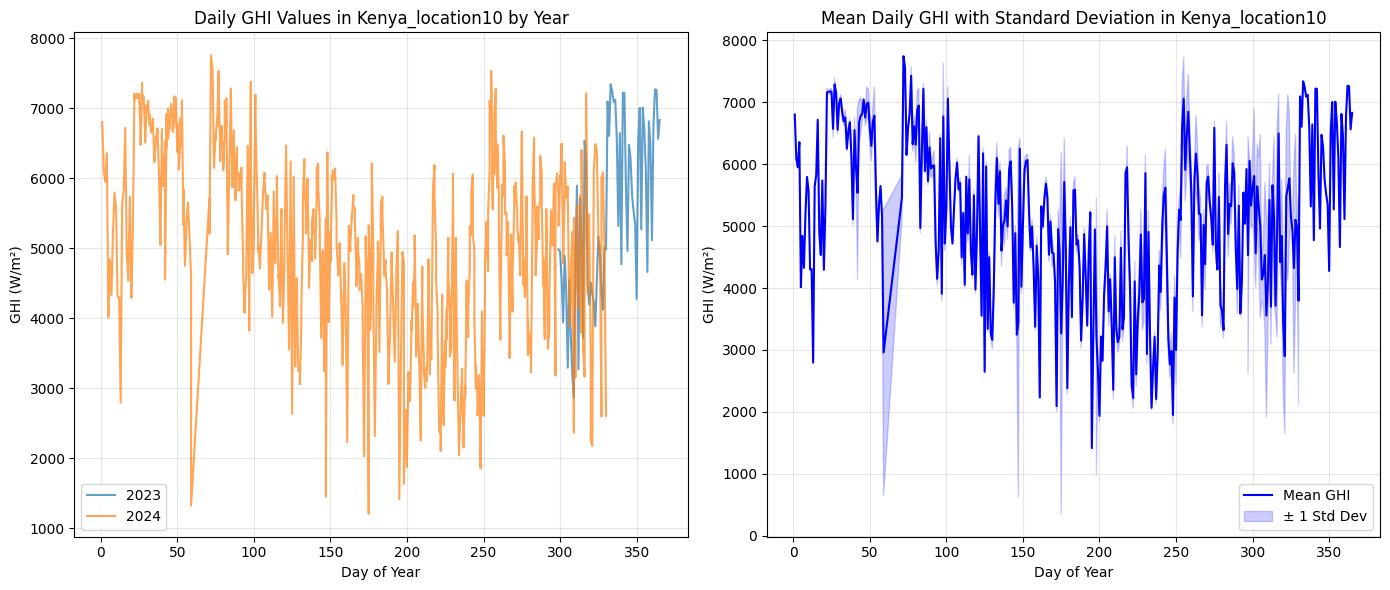

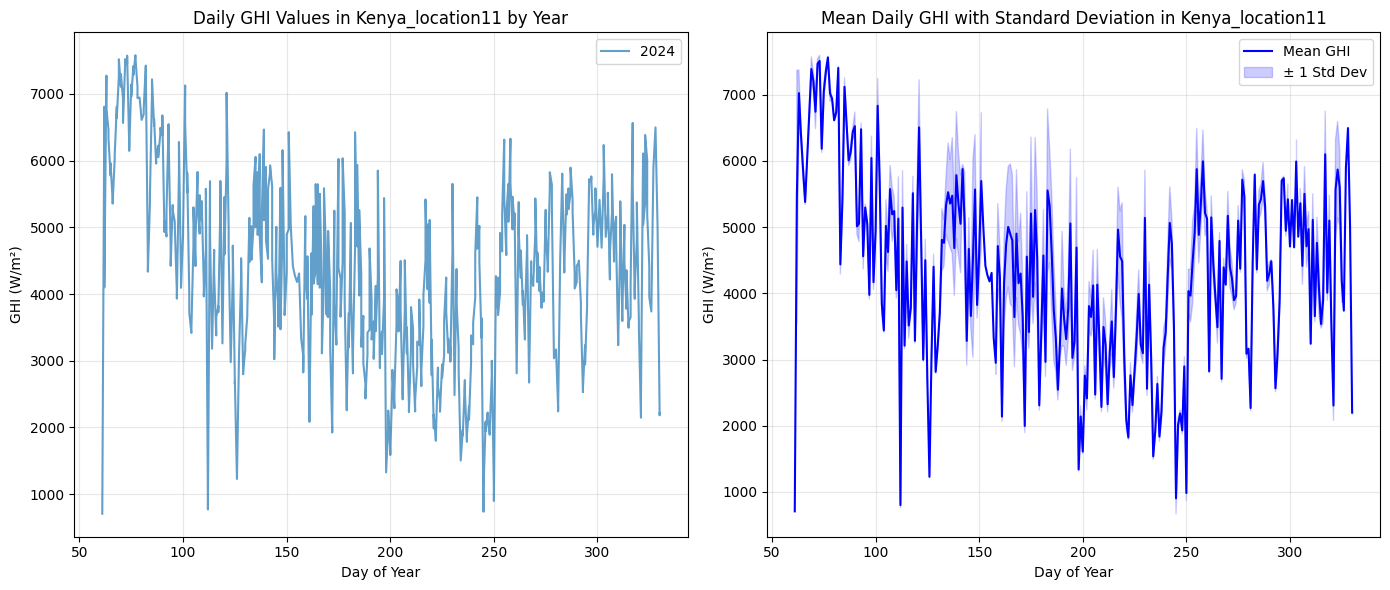

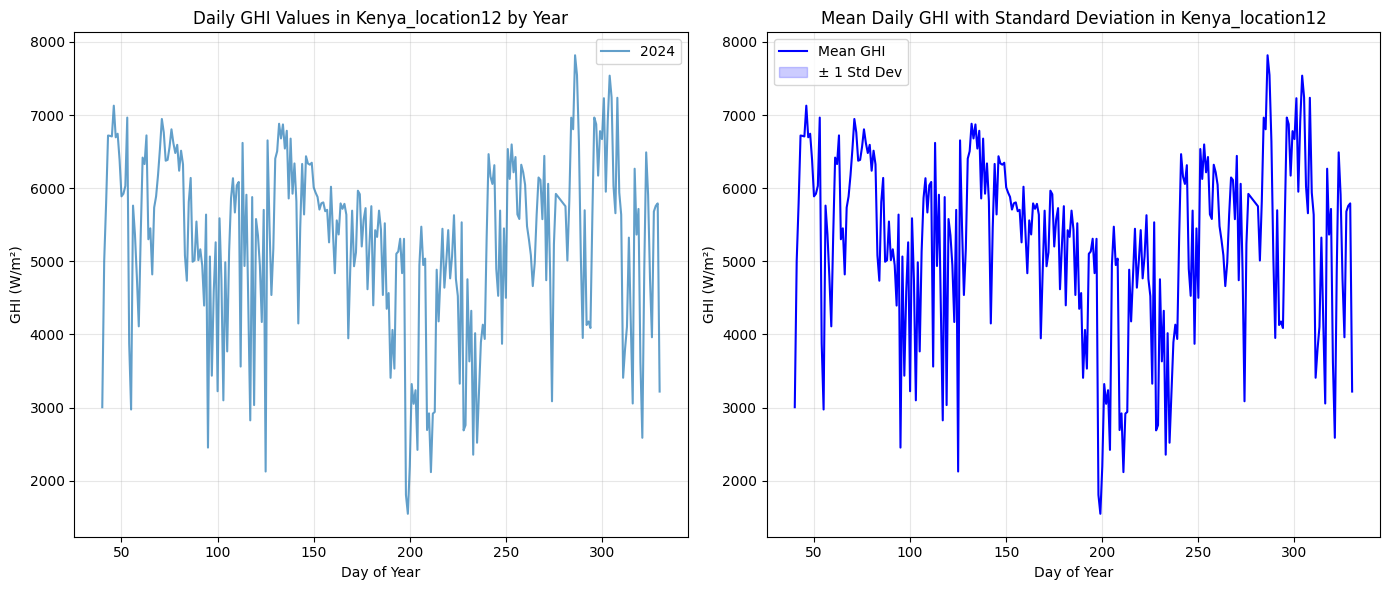

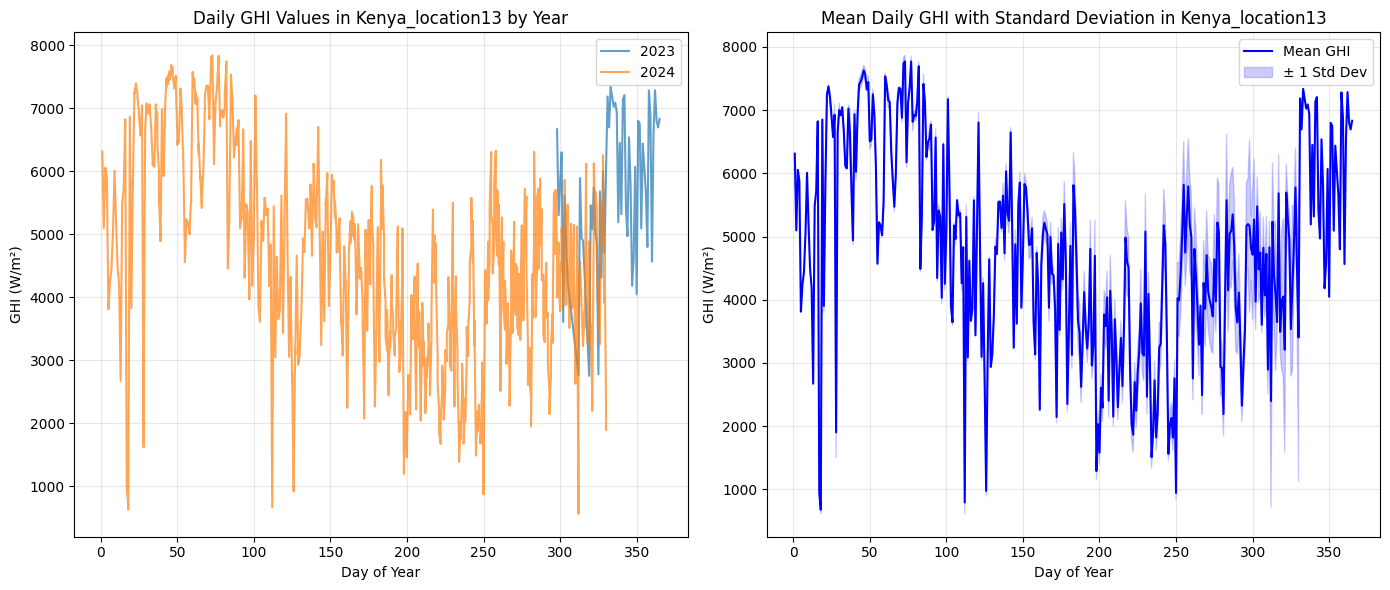

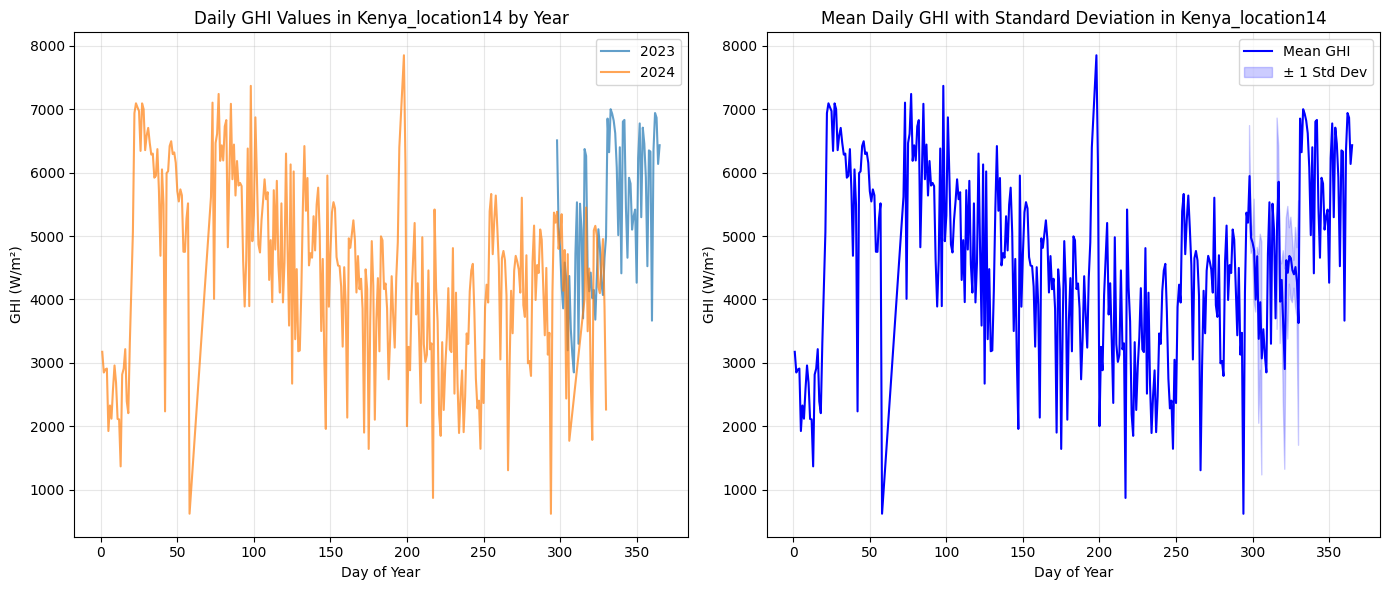

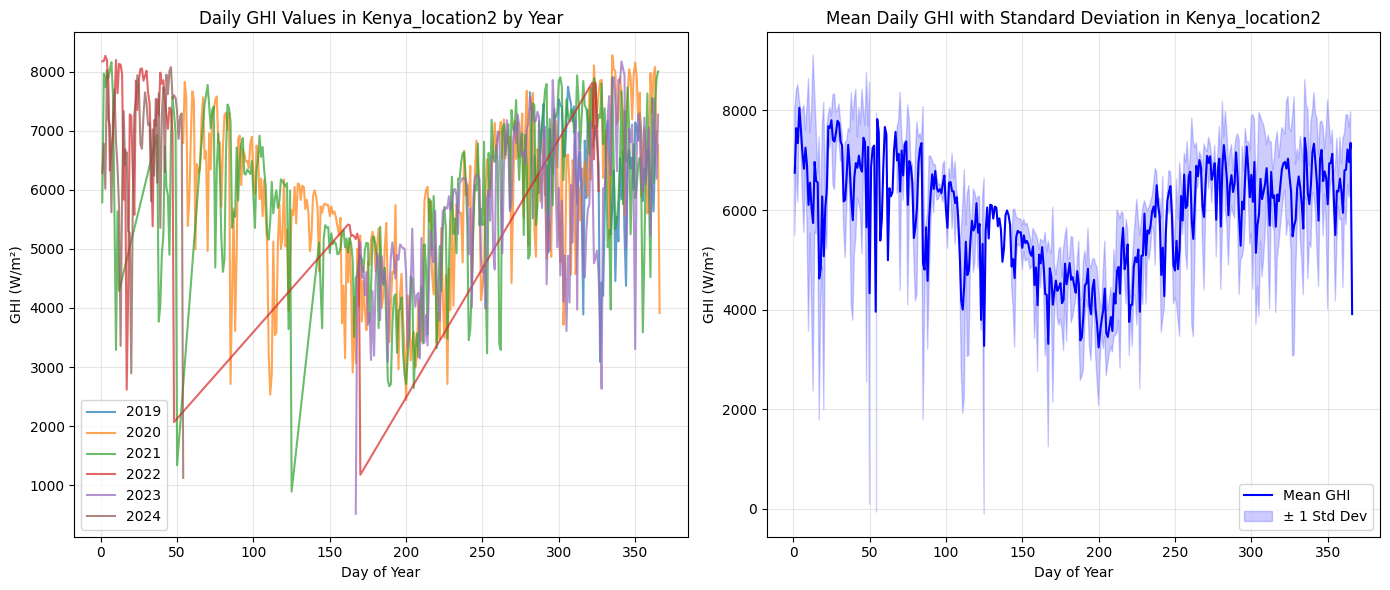

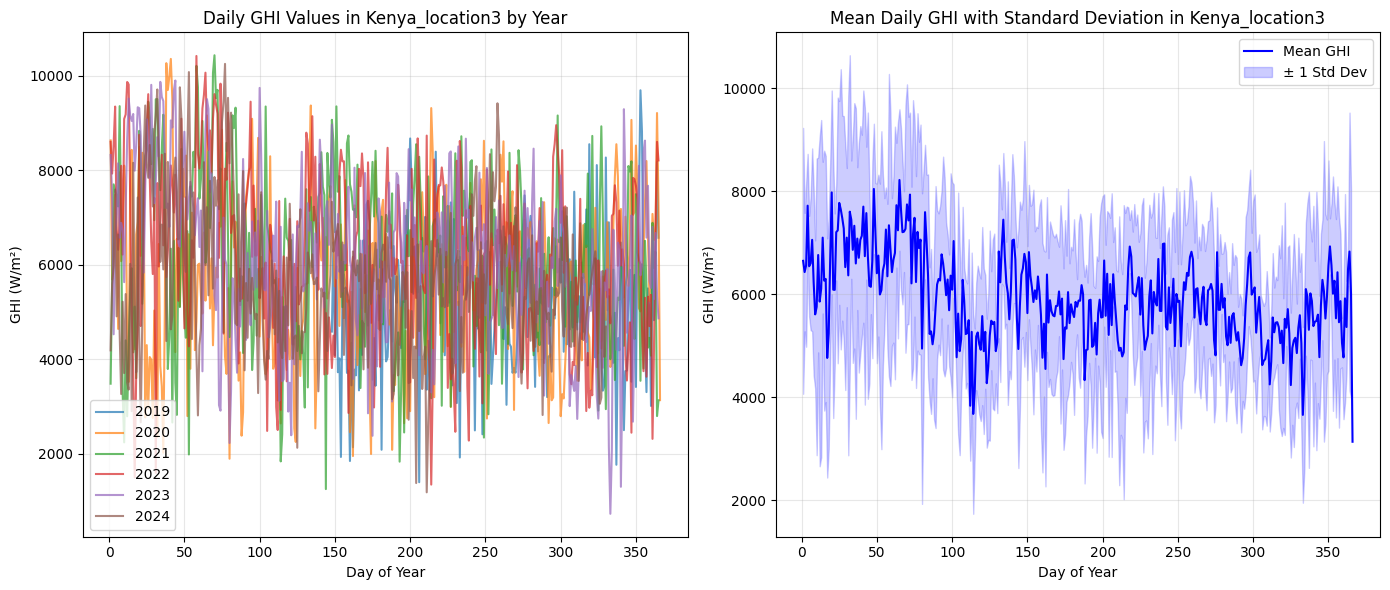

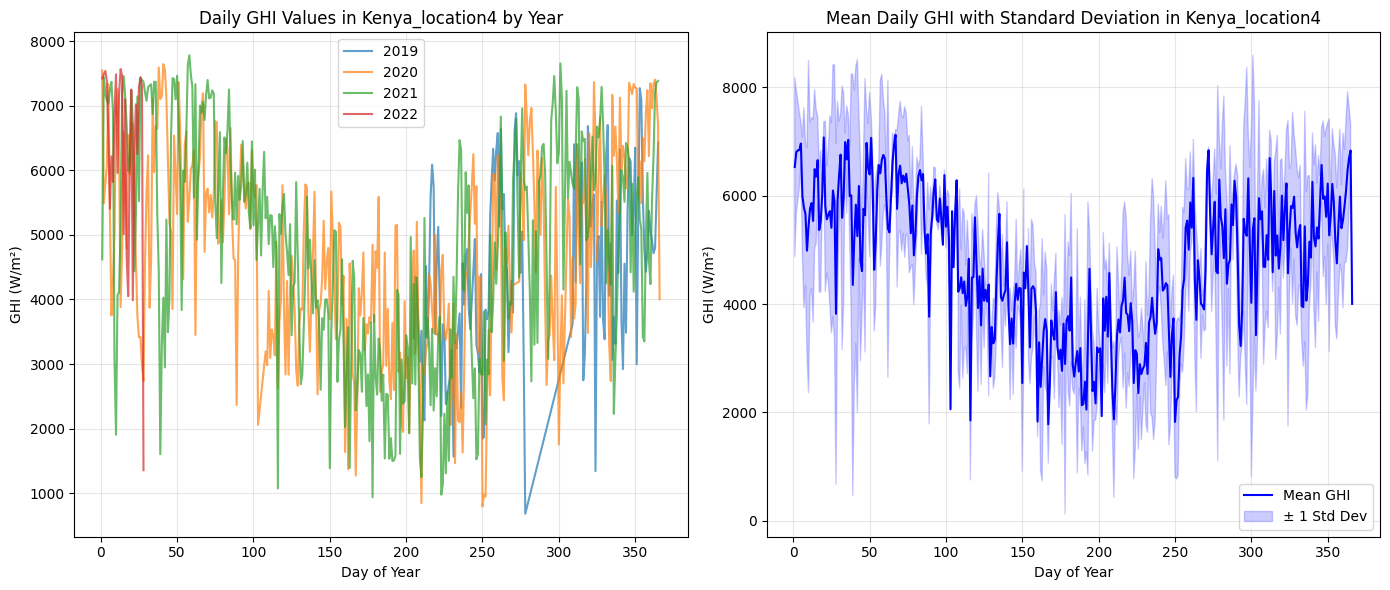

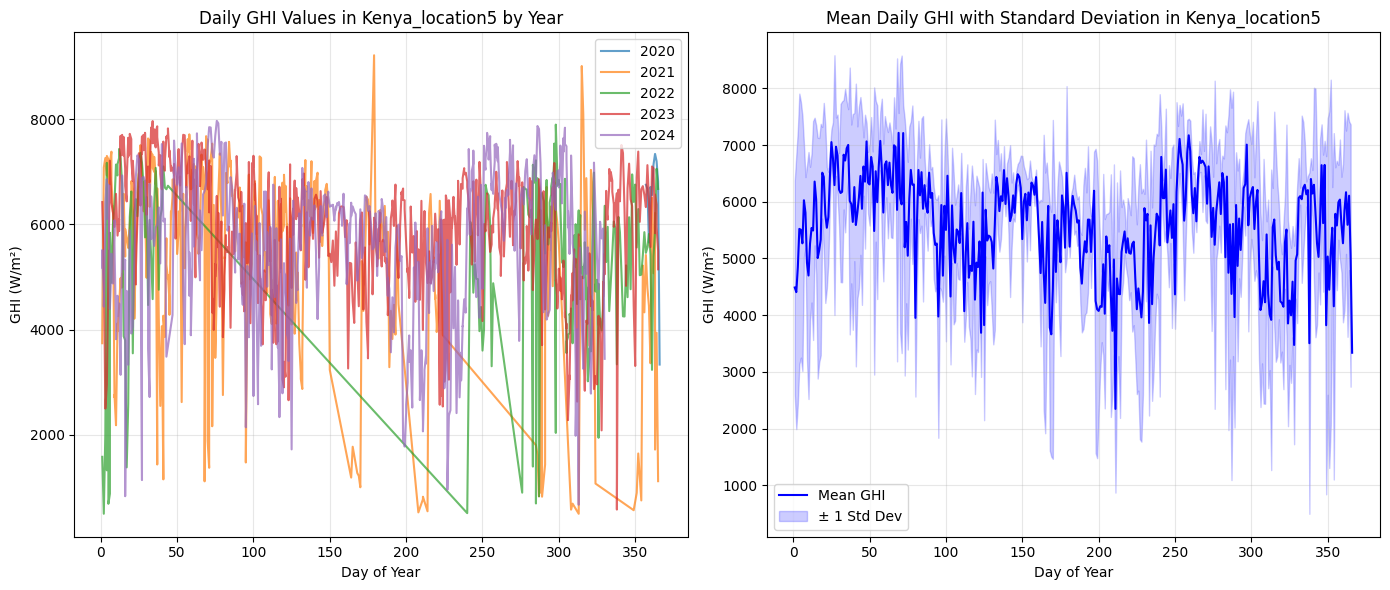

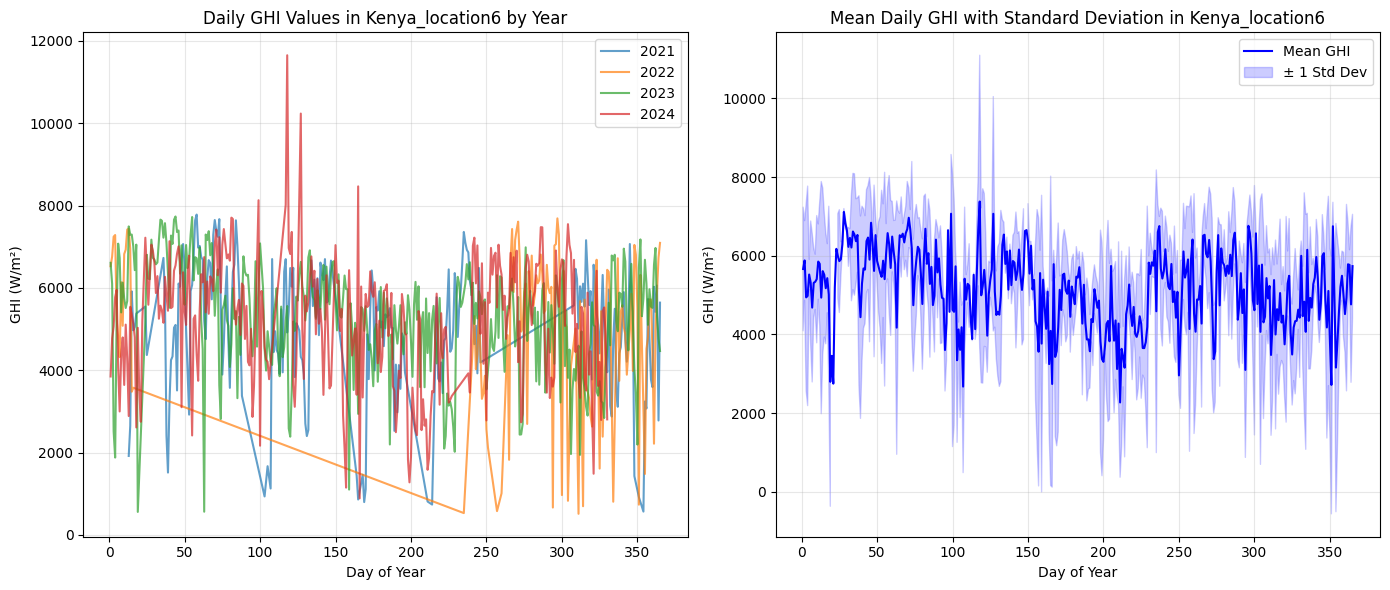

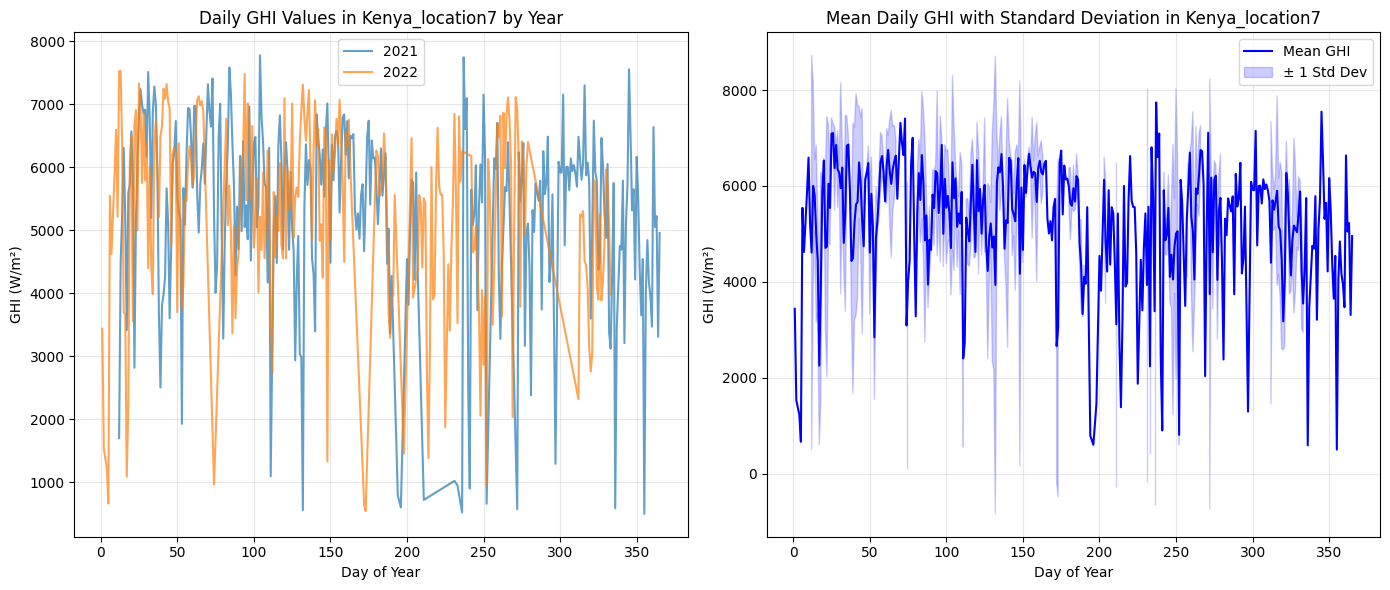

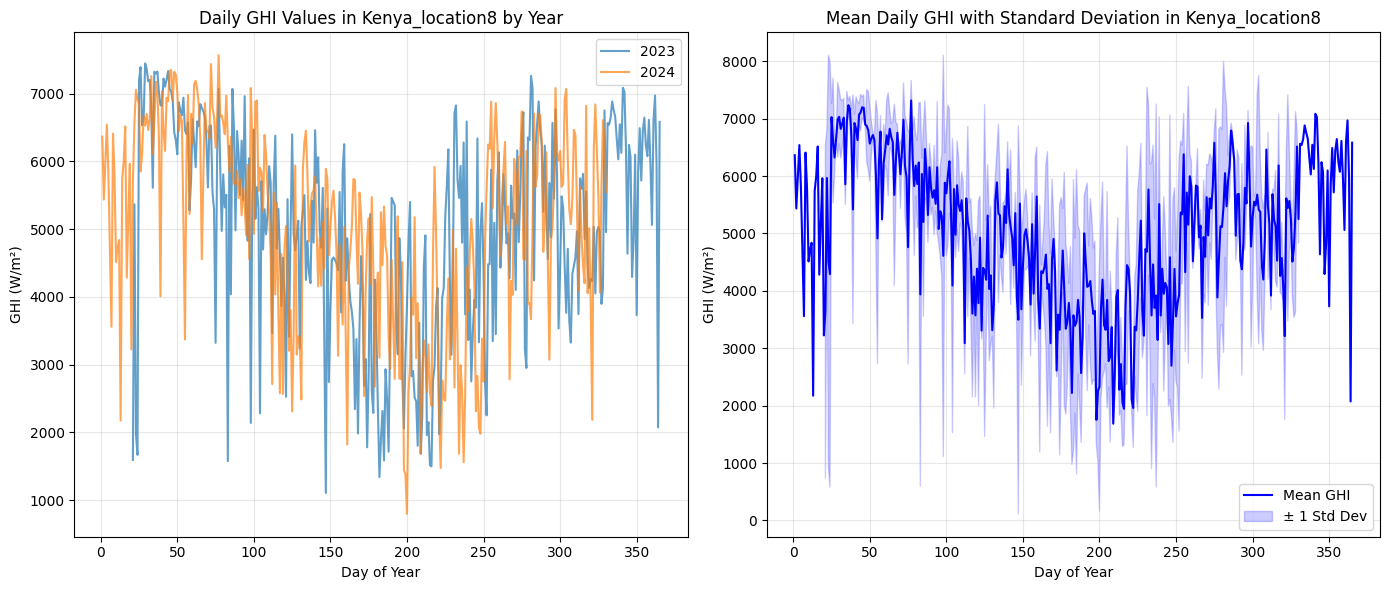

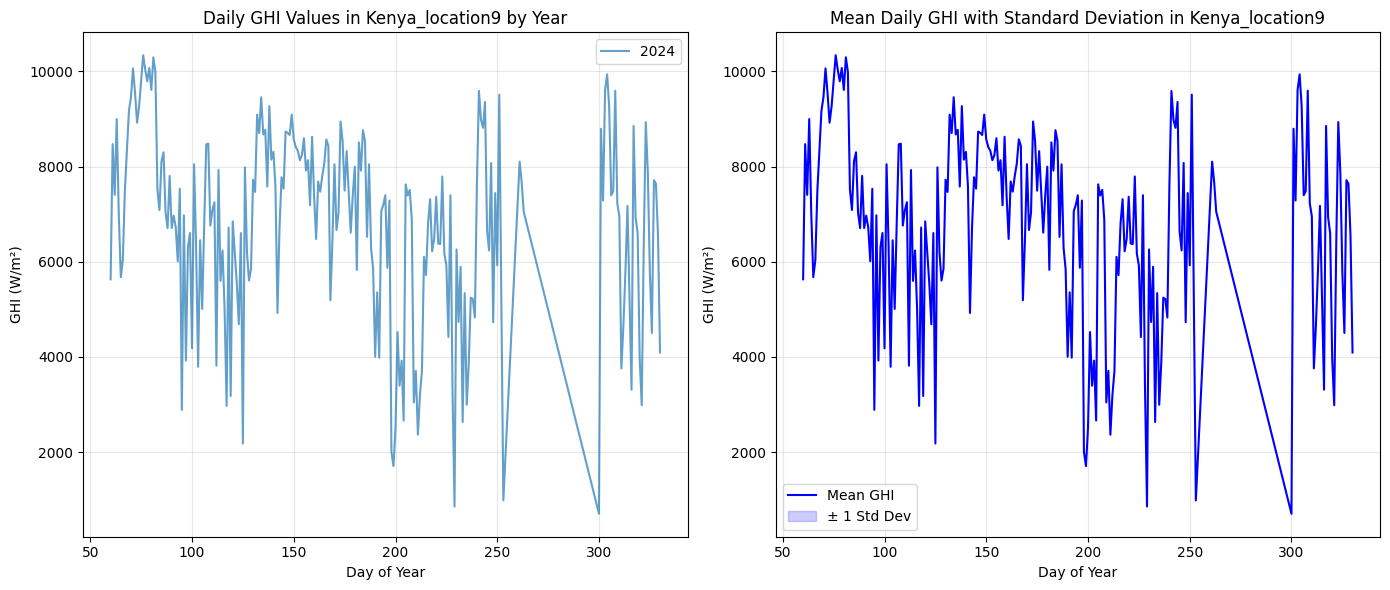

In [10]:
location = 'kenya'

data = pd.read_csv(CBE_measurement / f'{location}.csv')
data = drop_outliers(data)
figs, axes = plot_ghi_yearly_distribution(data)
plt.show()